# 🧬 Klasifikasi Kanker Payudara — Notebook Latihan Machine Learning

Kita akan membangun **model klasifikasi** untuk memprediksi apakah suatu tumor bersifat **ganas (malignant)** atau **jinak (benign)** menggunakan **dataset Breast Cancer Wisconsin (Diagnostic)**.

Dataset ini berisi hasil ekstraksi fitur dari citra digital sel kanker payudara, dan sering digunakan sebagai contoh klasik dalam machine learning untuk klasifikasi biner.

---

## 📘 **Alur Latihan Lengkap**
1) Persiapan environment & impor pustaka  
2) Memuat data (CSV atau bawaan sklearn)  
3)  pembersihan data:  
   - Menghapus kolom tak relevan (`id`, kolom kosong)  
   - Menangani *missing values* (contoh: `texture_mean`)  
   - Menghapus duplikat  
4) **Encoding** label target `diagnosis`:  
   - `M` → 1 (**Malignant**)  
   - `B` → 0 (**Benign**)  
5) Pembagian data latih dan uji (**train/test split**)  
6) Eksperimen model klasifikasi berbasis **Pipeline + GridSearchCV**  
   - **Model 1: Logistic Regression**  
     - Scaling → Feature Selection → Logistic Regression  
   - **Model 2: K-Nearest Neighbors (KNN)**  
     - Scaling → Feature Selection → KNN  
   - **Model 3: Random Forest**  
     - Scaling → Feature Selection → Random Forest  
7) Evaluasi tiap model:  
   - F1-score terbaik hasil *GridSearchCV*  
   - Akurasi pada data uji  
   - Fitur terbaik yang terpilih  
   - Confusion Matrix & Classification Report  
8) **Visualisasi Perbandingan Tiga Model Terbaik**  
   - Menampilkan *Confusion Matrix* ketiga model berdampingan  
---

>  **Catatan Penting:**
> - Pastikan file data bernama `wdbc.csv` sudah tersedia di direktori proyek.  
> - Langkah preprocessing (drop duplikat, encode label, tangani NaN) harus dilakukan sebelum *train/test split*.  
> - Semua model dioptimalkan menggunakan **GridSearchCV dengan StratifiedKFold (5-fold)** dan metrik utama **F1-score** untuk menjaga keseimbangan performa antara *precision* dan *recall*.

---

## 🎯 **Tujuan Akhir**
Notebook ini membantu mahasiswa memahami:
- Cara membangun **pipeline modular** untuk preprocessing dan model ML,  
- Penggunaan **GridSearchCV** untuk mencari parameter optimal,  
- Cara **membandingkan performa model** secara objektif melalui metrik dan visualisasi.

---

### 📈 **Model yang Dieksperimenkan**
| Model | Pipeline | Hyperparameter Utama | Keunggulan |
|--------|-----------|----------------------|-------------|
| **Logistic Regression** | `MinMaxScaler → SelectKBest → LogisticRegression` | `C`, `penalty` | Sederhana, interpretatif, cepat |
| **K-Nearest Neighbors (KNN)** | `MinMaxScaler → SelectKBest → KNN` | `n_neighbors`, `metric` | Mudah dipahami, berbasis jarak |
| **Random Forest** | `MinMaxScaler → SelectKBest → RandomForestClassifier` | `n_estimators`, `max_depth` | Kuat, menangani non-linearitas, fitur penting |

> ✨ **Hasil Akhir:**  
> Melalui pipeline dan tuning hyperparameter yang sistematis, kita dapat menentukan **model terbaik untuk memprediksi kanker payudara**, sekaligus memahami bagaimana tiap algoritma menangani data medis yang sensitif dan kompleks.


## **IMPORT LIBRARY**

In [1]:
# ============================================================
# 🧮 IMPORT LIBRARY — Pengolahan Data, Modeling, & Evaluasi
# ============================================================

# 📦 Manipulasi Data
import numpy as np
import pandas as pd                             # Silakan diisi bagian ini dengan kode yang tepat (1)

# 📊 Visualisasi
import matplotlib.pyplot as plt


# 🔧 Pembagian data & pencarian hyperparameter
from sklearn.model_selection import train_test_split          # Silakan diisi bagian ini dengan kode yang tepat (2)
from sklearn.model_selection import StratifiedKFold, GridSearchCV

# ⚙️ Pra-pemrosesan & Seleksi Fitur
from sklearn.preprocessing import MinMaxScaler
from sklearn.feature_selection import SelectKBest, SelectPercentile

# 🤖 Model Klasifikasi
from sklearn.linear_model import LogisticRegression               # Silakan diisi bagian ini dengan kode yang tepat (2)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier            # Silakan diisi bagian ini dengan kode yang tepat (2)


# 🧩 Pipeline & Utilitas
from sklearn.pipeline import Pipeline
from sklearn.base import clone
import time

# 📈 Evaluasi Model
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)


## **Loading Data**

In [2]:
df_cancer = pd.read_csv('wdbc.csv',header=0)

df_cancer.head()  # Silakan diisi bagian ini dengan kode yang tepat (1)

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [3]:
# Info cepat tentang kolom & tipe datanya
print("Jumlah baris, kolom:", df_cancer.shape)    # Silakan diisi bagian ini dengan kode yang tepat (1)
print("\nTipe data:")
print(df_cancer.dtypes)

Jumlah baris, kolom: (569, 32)

Tipe data:
id                           int64
diagnosis                   object
radius_mean                float64
texture_mean               float64
perimeter_mean             float64
area_mean                  float64
smoothness_mean            float64
compactness_mean           float64
concavity_mean             float64
concave points_mean        float64
symmetry_mean              float64
fractal_dimension_mean     float64
radius_se                  float64
texture_se                 float64
perimeter_se               float64
area_se                    float64
smoothness_se              float64
compactness_se             float64
concavity_se               float64
concave points_se          float64
symmetry_se                float64
fractal_dimension_se       float64
radius_worst               float64
texture_worst              float64
perimeter_worst            float64
area_worst                 float64
smoothness_worst           float64
compactness_

## **Pembersihan Data (Bagian 1): Buang Kolom Tak Perlu**
- Kolom `ID` tidak dibutuhkan untuk pemodelan (bukan ciri pasien dan terlalu unik), jadi kita hapus.


In [4]:
# 1) Hapus kolom 'id'
df_cancer2 = df_cancer.drop(columns=['id'], errors='ignore')  # Silakan diisi bagian ini dengan kode yang tepat (2)
df_cancer2.head()

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


## **Pembersihan Data (Bagian 2): Cek & Tangani Missing Value**
- Kita cek data **null/kosong/NaN** per kolom.  
- Kolom **`texture_mean`** memiliki beberapa nilai kosong dan diisi dengan **median** (aman saat kita belum tahu distribusinya).


In [5]:
# 1) Cek jumlah nilai kosong per kolom
print("Jumlah nilai kosong per kolom:\n", df_cancer2.isnull().sum())   # Silakan diisi bagian ini dengan kode yang tepat (2)

Jumlah nilai kosong per kolom:
 diagnosis                   0
radius_mean                 0
texture_mean               10
perimeter_mean              0
area_mean                   0
smoothness_mean             0
compactness_mean            0
concavity_mean              0
concave points_mean         0
symmetry_mean               0
fractal_dimension_mean      0
radius_se                   0
texture_se                  0
perimeter_se                0
area_se                     0
smoothness_se               0
compactness_se              0
concavity_se                0
concave points_se           0
symmetry_se                 0
fractal_dimension_se        0
radius_worst                0
texture_worst               0
perimeter_worst             0
area_worst                  0
smoothness_worst            0
compactness_worst           0
concavity_worst             0
concave points_worst        0
symmetry_worst              0
fractal_dimension_worst     0
dtype: int64


In [6]:
# 2) Contoh pengisian: gunakan median untuk kolom 'texture_mean' (jika ada)
median_chole = df_cancer2['texture_mean'].median()
df_cancer2['texture_mean'] = df_cancer2['texture_mean'].fillna(median_chole)
print("\nMedian texture_mean:", median_chole)


Median texture_mean: 18.87


In [7]:
# 3) Validasi ulang
print("\nSetelah imputasi, nilai kosong per kolom:\n", df_cancer2.isnull().sum())


Setelah imputasi, nilai kosong per kolom:
 diagnosis                  0
radius_mean                0
texture_mean               0
perimeter_mean             0
area_mean                  0
smoothness_mean            0
compactness_mean           0
concavity_mean             0
concave points_mean        0
symmetry_mean              0
fractal_dimension_mean     0
radius_se                  0
texture_se                 0
perimeter_se               0
area_se                    0
smoothness_se              0
compactness_se             0
concavity_se               0
concave points_se          0
symmetry_se                0
fractal_dimension_se       0
radius_worst               0
texture_worst              0
perimeter_worst            0
area_worst                 0
smoothness_worst           0
compactness_worst          0
concavity_worst            0
concave points_worst       0
symmetry_worst             0
fractal_dimension_worst    0
dtype: int64


## **Pembersihan Data (Bagian 3): Cek & Hapus Duplikat**
- Data yang **kembar** dapat merusak evaluasi model.
- Kita cek duplikat lalu **drop** agar setiap baris unik.


In [8]:
before = df_cancer2.shape
dupes = df_cancer2[df_cancer2.duplicated(keep=False)]
print(f"Jumlah baris duplikat (terhitung ganda): {dupes.shape[0]}")
df_cancer3 = df_cancer2.drop_duplicates(keep='first')
print("Bentuk data sebelum/ setelah hapus duplikat:", before, "->", df_cancer3.shape)

Jumlah baris duplikat (terhitung ganda): 0
Bentuk data sebelum/ setelah hapus duplikat: (569, 31) -> (569, 31)


##  **Encode Label & Pisahkan Fitur–Target**

- **Tujuan:** Mengubah kolom `diagnosis` dari huruf menjadi angka agar bisa diproses oleh model ML.  
  - `M` → 1 (**Malignant / Ganas**)  
  - `B` → 0 (**Benign / Jinak**)  

- Setelah itu, kita pisahkan:
  - **X** → semua kolom fitur (variabel independen)  
  - **y** → kolom target `diagnosis` (variabel dependen)


In [9]:
# Mengubah label diagnosis dari huruf menjadi angka:
df_cancer3['diagnosis'] = df_cancer3['diagnosis'].map({'M': 1, 'B' : 0})  # Silakan diisi bagian ini dengan kode yang tepat (2)

# Menentukan X sebagai fitur (semua kolom kecuali diagnosis)
X = df_cancer3.drop(columns=['diagnosis'])

# Menentukan y sebagai target (kolom diagnosis)
y = df_cancer3['diagnosis']

# Menampilkan 5 baris pertama dataframe setelah perubahan
df_cancer3.head()

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,1,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,1,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,1,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,1,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


## **Pembagian Data: Train/Test Split**

- **X**: semua fitur kecuali label target.  
- **y**: kolom target, yaitu `diagnosis` (1 = Malignant (ganas / “sakit”))
 atau (0 = Benign (jinak / “sehat”))
- Kita pakai **30%** data untuk **test** dan sisanya untuk **train**.


In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state = 42, stratify=y
)                                                           # Silakan diisi bagian ini dengan kode yang tepat (2)

print("Ukuran X_train, X_test:", X_train.shape, X_test.shape)


Ukuran X_train, X_test: (398, 30) (171, 30)


##  **Membangun Model Logistic Regression dengan Pipeline + GridSearchCV**

Langkah ini bertujuan untuk membangun model **klasifikasi Logistic Regression** secara sistematis menggunakan **pipeline** dan **GridSearchCV**.

### ⚙️ Alur Pipeline:
1. **Scaling (MinMaxScaler)**  
   Menyamakan skala fitur agar tiap kolom memiliki rentang yang sama (0–1).  
   → Penting untuk model yang sensitif terhadap perbedaan skala data seperti *Logistic Regression*.

2. **Feature Selection (SelectKBest)**  
   Memilih fitur terbaik berdasarkan skor statistik terhadap variabel target.  
   - `SelectKBest`: memilih *jumlah fitur tertentu (k)* yang paling relevan.

3. **Model (LogisticRegression)**  
   Model klasifikasi linear yang memprediksi probabilitas kelas target.  
   Parameter penting seperti:  
   - `penalty` dan `C` akan dioptimasi melalui **GridSearchCV**.  
   - `class_weight='balanced'` digunakan untuk menangani ketidakseimbangan jumlah kelas.  
   - `solver='liblinear'` dipilih karena mendukung penalti L1 maupun L2.


###  Tujuan GridSearchCV:
- **Mencari kombinasi parameter terbaik** untuk menghasilkan performa optimal.  
- Evaluasi dilakukan dengan **5-fold Stratified Cross Validation**,  
  menggunakan metrik **F1-score** (seimbang antara presisi dan recall).

Setelah pipeline dan parameter grid disiapkan, dilakukan proses pelatihan (`fit`) untuk menemukan model Logistic Regression terbaik.


In [11]:
# ============================================================
#  PIPELINE: Scaling → Feature Selection → Logistic Regression
# ============================================================

# Rancang pipeline: gabungkan preprocessing + feature selection + model
pipe_lr = Pipeline(steps=[
    ('scaler', MinMaxScaler()),             # Silakan diisi bagian ini dengan kode yang tepat (3)
    ('feat_select', SelectKBest()),        # Silakan diisi bagian ini dengan kode yang tepat (3)
    ('clf', LogisticRegression(      # model klasifikasi
        class_weight='balanced',        # Silakan diisi bagian ini dengan kode yang tepat (2)
        solver='liblinear',              # Silakan diisi bagian ini dengan kode yang tepat (2)
        max_iter=500              
    ))
])

# GridSearch: daftar kombinasi parameter yang akan diuji
params_grid_lr = [
    {
        'feat_select__k': np.arange(2, 10),             # jumlah fitur terbaik yang dicoba
        'clf__penalty': ['l1', 'l2'],                   # jenis regularisasi
        'clf__C': [0.01, 0.1, 1, 10],                   # kekuatan regularisasi
    },
    {
        'feat_select': [SelectPercentile()],                # alternatif: seleksi berdasar persentase
        'feat_select__percentile': np.arange(20, 80, 10),
        'clf__penalty': ['l1', 'l2'],
        'clf__C': [0.01, 0.1, 1, 10],
    }
]

# Stratified K-Fold: menjaga proporsi label seimbang di setiap fold CV
SKF = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Jalankan GridSearchCV untuk mencari kombinasi parameter terbaik
gscv_lr = GridSearchCV(
    pipe_lr,
    params_grid_lr,
    cv=SKF,
    scoring='f1',       # metrik utama: F1-score
    verbose=1,          # tampilkan progres selama proses
    n_jobs=-1           # gunakan semua core CPU
)

print("Menjalankan GridSearch untuk Logistic Regression...")
start = time.time()
gscv_lr.fit(X_train, y_train)
print(f"GridSearch Logistic Regression selesai dalam {time.time() - start:.2f} detik")


Menjalankan GridSearch untuk Logistic Regression...
Fitting 5 folds for each of 112 candidates, totalling 560 fits
GridSearch Logistic Regression selesai dalam 9.37 detik


##  **Evaluasi Model Logistic Regression**

Setelah proses *Grid Search* selesai, langkah berikutnya adalah **mengevaluasi performa model terbaik** yang ditemukan.

###  Langkah Evaluasi:
1. **Menampilkan hasil terbaik dari GridSearchCV**
   - Nilai *Cross Validation (CV) F1-score* tertinggi
   - Kombinasi parameter terbaik (fitur, penalti, dan nilai C)
2. **Menghitung akurasi pada data uji (test set)**  
   Untuk mengetahui seberapa baik model mengeneralisasi pada data baru.
3. **Melihat fitur yang terpilih**
   - Menggunakan metode `get_support()` dari *feature selector* untuk menampilkan fitur-fitur penting.
4. **Menampilkan Confusion Matrix**
   - Visualisasi hasil prediksi model terhadap label asli.
   - Memberi gambaran kesalahan klasifikasi antar kelas.
5. **Menampilkan Classification Report**
   - Metrik lengkap: *precision, recall, f1-score,* dan *support* untuk setiap kelas.
   - Membantu memahami performa model dalam konteks keseimbangan antara deteksi positif dan negatif.

>  Tujuan akhirnya adalah memastikan bahwa model Logistic Regression tidak hanya akurat,
> tetapi juga **seimbang dalam mendeteksi kedua kelas** (0 = sehat, 1 = sakit).


CV Score (F1) terbaik: 0.9526419155232715
Kombinasi model terbaik: {'clf__C': 10, 'clf__penalty': 'l2', 'feat_select': SelectPercentile(), 'feat_select__percentile': np.int64(70)}

Skor Test (akurasi) Logistic Regression: 0.9824561403508771

Fitur terbaik (terpilih): ['radius_mean' 'texture_mean' 'perimeter_mean' 'area_mean'
 'smoothness_mean' 'compactness_mean' 'concavity_mean'
 'concave points_mean' 'radius_se' 'perimeter_se' 'area_se'
 'concave points_se' 'radius_worst' 'texture_worst' 'perimeter_worst'
 'area_worst' 'smoothness_worst' 'compactness_worst' 'concavity_worst'
 'concave points_worst' 'symmetry_worst']


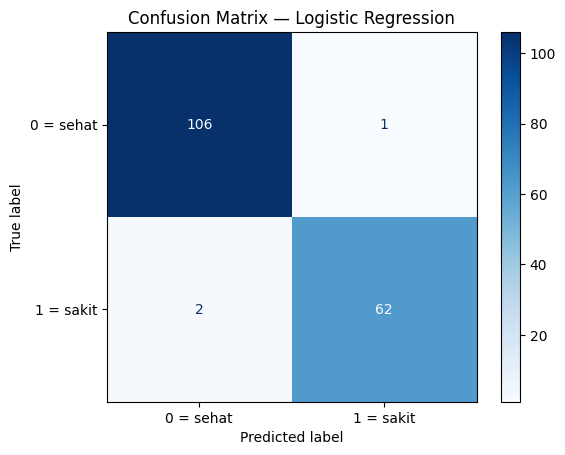


Classification Report — Logistic Regression:
               precision    recall  f1-score   support

           0       0.98      0.99      0.99       107
           1       0.98      0.97      0.98        64

    accuracy                           0.98       171
   macro avg       0.98      0.98      0.98       171
weighted avg       0.98      0.98      0.98       171



In [12]:
# Tampilkan hasil terbaik dari GridSearch
print("CV Score (F1) terbaik:", gscv_lr.best_score_)                  # Silakan diisi bagian ini dengan kode yang tepat (3)
print("Kombinasi model terbaik:", gscv_lr.best_params_)                # Silakan diisi bagian ini dengan kode yang tepat (3)

# Hitung akurasi model terbaik pada data uji
lr_test_score = gscv_lr.best_estimator_.score(X_test, y_test)
print("\nSkor Test (akurasi) Logistic Regression:", lr_test_score)

# Tampilkan fitur terbaik (jika feature selector mendukung metode get_support)
selector = gscv_lr.best_estimator_.named_steps['feat_select']
if hasattr(selector, 'get_support'):
    mask = selector.get_support()
    selected = np.array(X.columns)[mask]
    print("\nFitur terbaik (terpilih):", selected)

# Buat prediksi pada data uji dan tampilkan Confusion Matrix
lr_pred = gscv_lr.predict(X_test)
cm_lr = confusion_matrix(y_test, lr_pred)
disp_lr = ConfusionMatrixDisplay(confusion_matrix=cm_lr, display_labels=['0 = sehat','1 = sakit'])
disp_lr.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix — Logistic Regression")
plt.show()

# Tampilkan classification report (precision, recall, f1-score)
print("\nClassification Report — Logistic Regression:\n", classification_report(y_test, lr_pred))


##  **Membangun Model K-Nearest Neighbors (KNN) dengan Pipeline + GridSearchCV**

Langkah ini bertujuan untuk membangun dan mengoptimalkan model **K-Nearest Neighbors (KNN)** sebagai salah satu algoritma klasifikasi sederhana namun efektif.

###  Konsep KNN secara singkat:
KNN bekerja dengan **mengukur jarak** antara data uji dan data latih.  
Prediksi kelas ditentukan berdasarkan **K tetangga terdekat** (nearest neighbors).  
Semakin banyak tetangga dari kelas tertentu, semakin besar peluang data baru diklasifikasikan ke kelas tersebut.

###  Alur Pipeline:
1. **Scaling (MinMaxScaler)**  
   Karena KNN menghitung jarak antar titik data, semua fitur harus berada dalam **skala yang sama (0–1)** agar tidak ada fitur yang mendominasi.
2. **Feature Selection (SelectKBest)**  
   Menyaring fitur-fitur terbaik berdasarkan nilai statistik:
   - `SelectKBest`: memilih jumlah fitur tertentu (misal 3–10)
3. **Model (KNeighborsClassifier)**  
   Parameter penting:
   - `n_neighbors`: jumlah tetangga yang dipertimbangkan  
   - `weights`: bobot kontribusi tiap tetangga (`uniform` atau `distance`)  
   - `metric`: jenis perhitungan jarak (`euclidean` atau `manhattan`)

###  **Tujuan GridSearchCV**:
Melakukan **pencarian otomatis kombinasi parameter terbaik** untuk KNN, dengan evaluasi berbasis **5-fold Stratified Cross Validation** menggunakan metrik **F1-score** (seimbang antara presisi dan recall).

Output dari sel ini:
- Proses pencarian model KNN terbaik  
- Lama waktu pelatihan  
- Kombinasi parameter dan selektor fitur optimal


In [13]:
# ============================================================
# 💡 PIPELINE: Scaling → Feature Selection → K-Nearest Neighbors
# ============================================================

# Rancang pipeline: gabungkan preprocessing + feature selection + model
pipe_knn = Pipeline(steps=[
    ('scaler', MinMaxScaler()),         # normalisasi fitur agar jarak antar data sebanding
    ('feat_select', SelectKBest()),     # pilih fitur numerik terbaik berdasarkan skor statistik
    ('clf', KNeighborsClassifier())     # model KNN untuk klasifikasi
])

# GridSearch: kombinasi parameter yang akan diuji
params_grid_knn = [
    # Kandidat 1: SelectKBest
    {
        'feat_select__k': np.arange(3, 10),       # jumlah fitur terbaik yang dicoba
        'clf__n_neighbors': [3, 5, 7, 9, 11],     # jumlah tetangga (K)
        'clf__weights': ['uniform', 'distance'],    # Silakan diisi bagian ini dengan kode yang tepat (2)
        'clf__metric': ['euclidean', 'manhattan']    # Silakan diisi bagian ini dengan kode yang tepat (2)
    },
    # Kandidat 2: SelectPercentile
    {
        'feat_select': [SelectPercentile()],                 # alternatif seleksi fitur berdasar persentase
        'feat_select__percentile': np.arange(20, 80, 10),
        'clf__n_neighbors': [3, 5, 7, 9, 11],
        'clf__weights': ['uniform', 'distance'],  # Silakan diisi bagian ini dengan kode yang tepat (2)
        'clf__metric': ['euclidean', 'manhattan']   # Silakan diisi bagian ini dengan kode yang tepat (2)
    }
]

# Stratified K-Fold: memastikan proporsi kelas tetap seimbang di setiap fold
SKF = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)            # Silakan diisi bagian ini dengan kode yang tepat (3)

# Jalankan GridSearchCV untuk mencari parameter terbaik dengan metrik F1
gscv_knn = GridSearchCV(
    pipe_knn,
    params_grid_knn,
    cv=SKF,
    scoring='f1',       # gunakan F1-score karena dataset bisa tidak seimbang
    verbose=1,          # tampilkan progres selama proses
    n_jobs=-1           # gunakan semua core CPU untuk mempercepat
)

print("Menjalankan GridSearch untuk K-Nearest Neighbors...")
start = time.time()
gscv_knn.fit(X_train, y_train)                                          # latih model dan cari kombinasi parameter terbaik
print(f"GridSearch KNN selesai dalam {time.time() - start:.2f} detik")


Menjalankan GridSearch untuk K-Nearest Neighbors...
Fitting 5 folds for each of 260 candidates, totalling 1300 fits
GridSearch KNN selesai dalam 3.35 detik


##  **Evaluasi Model K-Nearest Neighbors (KNN)**

Setelah proses *Grid Search* selesai, langkah berikutnya adalah **mengevaluasi model terbaik** yang ditemukan untuk memastikan performanya optimal.

###  Langkah-langkah evaluasi:
1. **Menampilkan hasil terbaik dari GridSearchCV**
   - Nilai *Cross Validation (CV) F1-score* tertinggi  
   - Kombinasi parameter (K, metrik jarak, dan jumlah fitur) terbaik
2. **Menghitung akurasi pada data uji (test set)**  
   Untuk melihat performa model terhadap data baru.
3. **Menampilkan fitur yang terpilih**
   - Melalui `get_support()` dari *feature selector* untuk mengetahui fitur paling berpengaruh.
4. **Menampilkan Confusion Matrix**
   - Visualisasi perbandingan antara prediksi dan label asli.
   - Memudahkan untuk melihat berapa banyak kasus salah klasifikasi antar kelas.
5. **Menampilkan Classification Report**
   - Metrik lengkap: *precision, recall, f1-score,* dan *support* per kelas.
   - Memberikan pemahaman mendalam terhadap keseimbangan performa model.

>  Tujuan utama evaluasi ini adalah memastikan model KNN tidak hanya akurat,
> tetapi juga mampu mendeteksi **kedua kelas secara adil** (0 = sehat, 1 = sakit),
> tanpa bias ke salah satu sisi.


CV Score (F1) terbaik: 0.9534223591850711
Kombinasi model terbaik: Pipeline(steps=[('scaler', MinMaxScaler()),
                ('feat_select', SelectPercentile(percentile=np.int64(70))),
                ('clf',
                 KNeighborsClassifier(metric='euclidean', n_neighbors=9,
                                      weights='distance'))])

Skor Test (akurasi) KNN: 0.9707602339181286

Fitur terbaik (terpilih): ['radius_mean' 'texture_mean' 'perimeter_mean' 'area_mean'
 'smoothness_mean' 'compactness_mean' 'concavity_mean'
 'concave points_mean' 'radius_se' 'perimeter_se' 'area_se'
 'concave points_se' 'radius_worst' 'texture_worst' 'perimeter_worst'
 'area_worst' 'smoothness_worst' 'compactness_worst' 'concavity_worst'
 'concave points_worst' 'symmetry_worst']


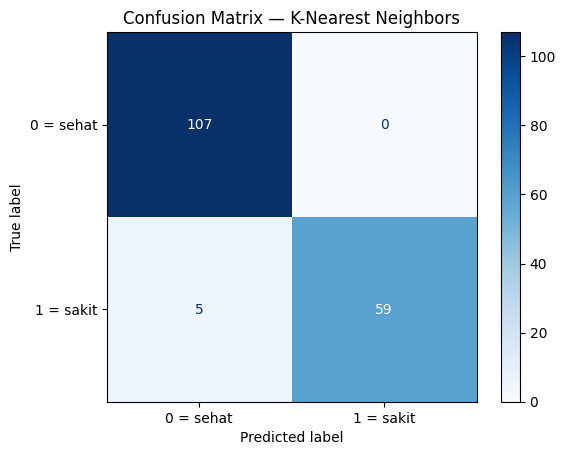


Classification Report — K-Nearest Neighbors:
               precision    recall  f1-score   support

           0       0.96      1.00      0.98       107
           1       1.00      0.92      0.96        64

    accuracy                           0.97       171
   macro avg       0.98      0.96      0.97       171
weighted avg       0.97      0.97      0.97       171



In [14]:
#  Evaluasi hasil GridSearch
print("CV Score (F1) terbaik:", gscv_knn.best_score_)
print("Kombinasi model terbaik:", gscv_knn.best_estimator_)

knn_test_score = gscv_knn.best_estimator_.score(X_test, y_test)         # Silakan diisi bagian ini dengan kode yang tepat (3)
print("\nSkor Test (akurasi) KNN:", knn_test_score)                 # Silakan diisi bagian ini dengan kode yang tepat (2)

#  Fitur terbaik (jika selector mendukung get_support)
selector = gscv_knn.best_estimator_.named_steps['feat_select']
if hasattr(selector, 'get_support'):
    mask = selector.get_support()
    selected = np.array(X.columns)[mask]
    print("\nFitur terbaik (terpilih):", selected)

#  Confusion Matrix & Classification Report
knn_pred = gscv_knn.predict(X_test)
cm_knn = confusion_matrix(y_test, knn_pred)
disp_knn = ConfusionMatrixDisplay(confusion_matrix=cm_knn, display_labels=['0 = sehat','1 = sakit'])                # Silakan diisi bagian ini dengan kode yang tepat (3)
disp_knn.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix — K-Nearest Neighbors")
plt.show()

print("\nClassification Report — K-Nearest Neighbors:\n", classification_report(y_test, knn_pred))  # Silakan diisi bagian ini dengan kode yang tepat (2)


##  **Membangun Model Random Forest dengan Pipeline + GridSearchCV**

Pada bagian ini, kita akan membangun model **Random Forest Classifier** — salah satu algoritma ensemble paling populer dan kuat untuk tugas klasifikasi.

###  Konsep Singkat Random Forest:
Random Forest bekerja dengan membangun **banyak pohon keputusan (decision trees)** secara acak, kemudian menggabungkan hasilnya untuk menghasilkan prediksi akhir yang lebih stabil dan akurat.  
-> Semakin banyak pohon, semakin kuat generalisasi model, meski waktu komputasi juga meningkat.

###  Alur Pipeline:
1. **Scaling (MinMaxScaler)**  
   Tidak wajib untuk Random Forest (karena berbasis pohon), tetapi tetap digunakan agar pipeline konsisten dengan model lain seperti SVM atau Logistic Regression.
2. **Feature Selection (SelectKBest / SelectPercentile)**  
   Menyaring fitur yang paling berpengaruh terhadap target:  
   - `SelectKBest`: memilih *jumlah fitur terbaik (k)*  
   - `SelectPercentile`: memilih *persentase fitur terbaik (%)*  
3. **Model (RandomForestClassifier)**  
   Parameter penting yang diuji:
   - `n_estimators`: jumlah pohon dalam hutan  
   - `max_depth`: kedalaman maksimum tiap pohon  
   - `min_samples_split`: jumlah minimum sampel agar cabang pohon dapat dipecah  
   - `class_weight='balanced'`: menyeimbangkan bobot antar kelas


###  Tujuan GridSearchCV:
Melakukan **pencarian otomatis kombinasi parameter terbaik** untuk menghasilkan model dengan performa optimal,  
dengan evaluasi menggunakan **5-fold Stratified Cross Validation** dan metrik **F1-score**.

Output dari cell ini:
- Model Random Forest terbaik  
- Waktu komputasi total  
- Parameter optimal hasil pencarian GridSearch


In [15]:
# ============================================================
#  PIPELINE: Scaling → Feature Selection → Random Forest
# ============================================================


# Rancang pipeline: gabungkan scaling, seleksi fitur, dan model Random Forest
pipe_rf = Pipeline(steps=[
    ('scaler', MinMaxScaler()),              # Silakan diisi bagian ini dengan kode yang tepat (3)
    ('feat_select', SelectKBest()),              # Silakan diisi bagian ini dengan kode yang tepat (3)
    ('clf', RandomForestClassifier(      # Silakan diisi bagian ini dengan kode yang tepat (3)
        class_weight='balanced',       # Silakan diisi bagian ini dengan kode yang tepat (2)
        random_state=42,            # Silakan diisi bagian ini dengan kode yang tepat (2)   
        n_jobs=-1                      # Silakan diisi bagian ini dengan kode yang tepat (2)  
    ))
])

# GridSearch: dua jenis seleksi fitur (KBest dan Percentile) dengan kombinasi parameter model
params_grid_rf = [
    # Kandidat 1: pakai SelectKBest
    {
        'feat_select__k': np.arange(5, 15),        # jumlah fitur terbaik yang diuji
        'clf__n_estimators': [100, 300, 500],      # jumlah pohon
        'clf__max_depth': [None, 5, 10],           # batas kedalaman tiap pohon
        'clf__min_samples_split': [2, 5, 10]       # jumlah minimal sampel untuk split node
    },
    # Kandidat 2: pakai SelectPercentile
    {
        'feat_select': [SelectPercentile()],
        'feat_select__percentile': np.arange(30, 80, 10),
        'clf__n_estimators': [100, 300, 500],
        'clf__max_depth': [None, 5, 10],
        'clf__min_samples_split': [2, 5, 10]
    }
]

# StratifiedKFold: memastikan proporsi kelas tetap sama di setiap fold CV
SKF = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)                 # Silakan diisi bagian ini dengan kode yang tepat (4)

# Jalankan GridSearchCV: mencari kombinasi parameter terbaik dengan metrik F1
gscv_rf = GridSearchCV(
    pipe_rf,                 # Silakan diisi bagian ini dengan kode yang tepat (2)
    params_grid_rf,                 # Silakan diisi bagian ini dengan kode yang tepat (2)
    cv=SKF,         # Silakan diisi bagian ini dengan kode yang tepat (2)
    scoring='f1',       # Silakan diisi bagian ini dengan kode yang tepat (2)
    verbose=1,         # Silakan diisi bagian ini dengan kode yang tepat (1)
    n_jobs=-1         # Silakan diisi bagian ini dengan kode yang tepat (1)
)

print("Menjalankan GridSearch untuk Random Forest...")
start = time.time()

gscv_rf.fit(X_train, y_train)      # Silakan diisi bagian ini dengan kode yang tepat (3)

print(f"GridSearch Random Forest selesai dalam {time.time() - start:.2f} detik")


Menjalankan GridSearch untuk Random Forest...
Fitting 5 folds for each of 405 candidates, totalling 2025 fits
GridSearch Random Forest selesai dalam 90.81 detik


##  **Evaluasi Model Random Forest**

Setelah GridSearchCV selesai, langkah berikutnya adalah **mengevaluasi performa model terbaik** yang ditemukan terhadap data uji.

###  Langkah Evaluasi:
1. **Menampilkan hasil terbaik dari GridSearchCV**
   - Nilai *Cross Validation (CV) F1-score* tertinggi  
   - Kombinasi parameter terbaik (jumlah pohon, kedalaman, dan jumlah fitur)
2. **Mengukur akurasi pada data uji (test set)**  
   Untuk menilai seberapa baik model mampu mengeneralisasi data baru.
3. **Menampilkan fitur yang terpilih**
   - Menggunakan `get_support()` untuk mengetahui fitur mana yang dianggap paling relevan oleh model.
4. **Menampilkan Confusion Matrix**
   - Visualisasi perbandingan prediksi dan label sebenarnya.  
   - Warna hijau digunakan untuk membedakan hasil Random Forest dari model lain.
5. **Menampilkan Classification Report**
   - Metrik lengkap: *precision*, *recall*, *f1-score*, dan *support* tiap kelas.
   - Membantu memahami keseimbangan performa model dalam mendeteksi kedua kelas (sehat vs sakit).

>  Tujuan utama evaluasi ini adalah memastikan model **tidak hanya akurat**,  
> tetapi juga **mampu mengenali kedua kelas secara seimbang**, terutama jika data sedikit tidak seimbang.


CV Score (F1) terbaik: 0.9383701074765088
Kombinasi model terbaik: {'clf__max_depth': None, 'clf__min_samples_split': 2, 'clf__n_estimators': 300, 'feat_select': SelectPercentile(), 'feat_select__percentile': np.int64(70)}

Skor Test (akurasi) Random Forest: 0.9766081871345029

Fitur terbaik (terpilih): ['radius_mean' 'texture_mean' 'perimeter_mean' 'area_mean'
 'smoothness_mean' 'compactness_mean' 'concavity_mean'
 'concave points_mean' 'radius_se' 'perimeter_se' 'area_se'
 'concave points_se' 'radius_worst' 'texture_worst' 'perimeter_worst'
 'area_worst' 'smoothness_worst' 'compactness_worst' 'concavity_worst'
 'concave points_worst' 'symmetry_worst']


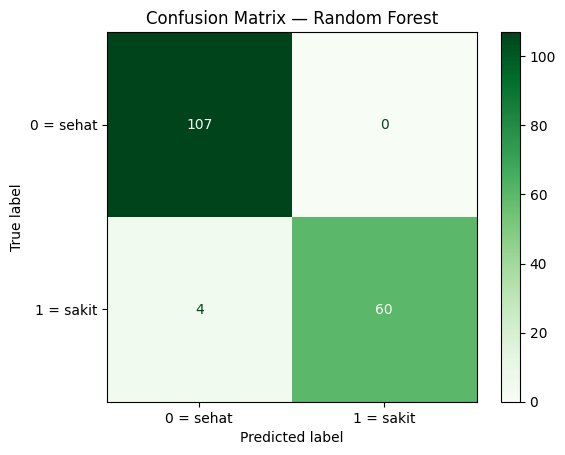


Classification Report — Random Forest:
               precision    recall  f1-score   support

           0       0.96      1.00      0.98       107
           1       1.00      0.94      0.97        64

    accuracy                           0.98       171
   macro avg       0.98      0.97      0.97       171
weighted avg       0.98      0.98      0.98       171



In [16]:
#  Evaluasi hasil GridSearch
print("CV Score (F1) terbaik:", gscv_rf.best_score_)        # Silakan diisi bagian ini dengan kode yang tepat (3)
print("Kombinasi model terbaik:", gscv_rf.best_params_)      # Silakan diisi bagian ini dengan kode yang tepat (3)

rf_test_score = gscv_rf.best_estimator_.score(X_test, y_test) # Silakan diisi bagian ini dengan kode yang tepat (3)
print("\nSkor Test (akurasi) Random Forest:", rf_test_score)  # Silakan diisi bagian ini dengan kode yang tepat (2)

#  Fitur terbaik (jika selector mendukung get_support)
selector = gscv_rf.best_estimator_.named_steps['feat_select']
if hasattr(selector, 'get_support'):
    mask = selector.get_support()
    selected = np.array(X.columns)[mask]
    print("\nFitur terbaik (terpilih):", selected)

#  Confusion Matrix & Classification Report
rf_pred = gscv_rf.predict(X_test)              # Silakan diisi bagian ini dengan kode yang tepat (2)
cm_rf = confusion_matrix(y_test, rf_pred)      # Silakan diisi bagian ini dengan kode yang tepat (2)
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=['0 = sehat','1 = sakit'])  # Silakan diisi bagian ini dengan kode yang tepat (3)
disp_rf.plot(cmap=plt.cm.Greens)
plt.title("Confusion Matrix — Random Forest")
plt.show()

# Silakan diisi bagian ini dengan kode yang tepat ()
print("\nClassification Report — Random Forest:\n", classification_report(y_test, rf_pred))  # Silakan diisi bagian ini dengan kode yang tepat (2)


## **Langkah Akhir — Visualisasi Perbandingan Tiga Model Terbaik**

Pada tahap ini, kita akan membandingkan **hasil klasifikasi dari tiga model terbaik** yang telah dibangun menggunakan **Pipeline + GridSearchCV**:

- **Logistic Regression** → dengan optimasi regularisasi (`penalty`, `C`) dan seleksi fitur terbaik  
- **K-Nearest Neighbors (KNN)** → dengan optimasi jumlah tetangga (`n_neighbors`), metrik jarak, dan seleksi fitur  
- **Random Forest** → dengan optimasi jumlah pohon (`n_estimators`), kedalaman maksimum (`max_depth`), dan fitur terbaik  

### **Tujuan:**
Menampilkan **Confusion Matrix** dari ketiga model secara berdampingan, agar kita dapat:
- Membandingkan pola kesalahan klasifikasi tiap model.  
- Melihat model mana yang **paling akurat** dan **paling seimbang** dalam mengenali kedua kelas:  
  - `0 = sehat (benign)`  
  - `1 = sakit (malignant)`  

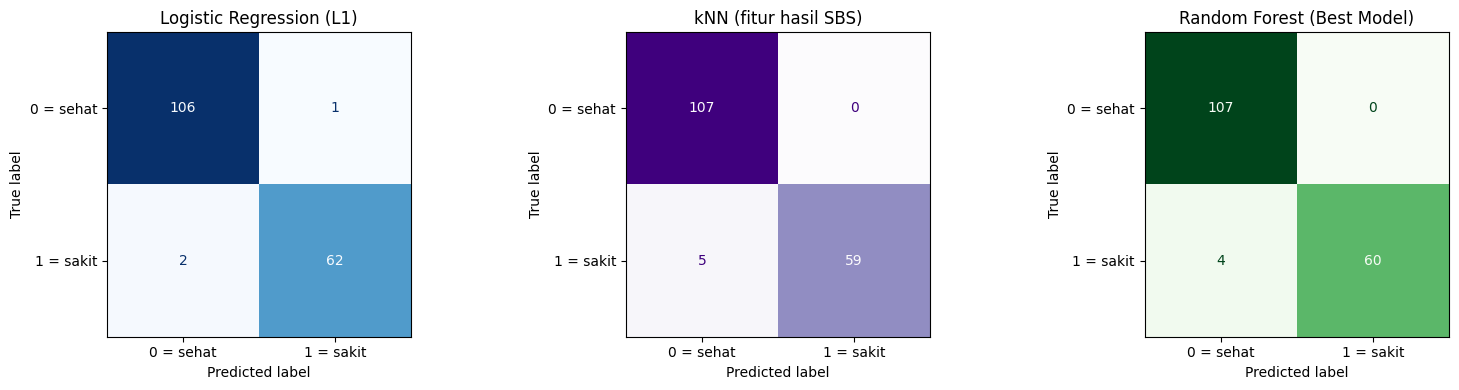

In [17]:
# Buat figure dengan 3 subplot berdampingan (1 baris, 3 kolom)
fig, (ax1, ax2, ax3) = plt.subplots(ncols=3, figsize=(16, 4))

# Plot Confusion Matrix untuk Logistic Regression
disp_lr.plot(ax=ax1, cmap=plt.cm.Blues, colorbar=False)
ax1.set_title("Logistic Regression (L1)")   # judul subplot pertama

# Plot Confusion Matrix untuk KNN
disp_knn.plot(ax=ax2, cmap=plt.cm.Purples, colorbar=False)
ax2.set_title("kNN (fitur hasil SBS)")      # judul subplot kedua

# Plot Confusion Matrix untuk Random Forest
disp_rf.plot(ax=ax3, cmap=plt.cm.Greens, colorbar=False)
ax3.set_title("Random Forest (Best Model)") # judul subplot ketiga

# Rapikan tata letak agar subplot tidak tumpang tindih
plt.tight_layout()
plt.show()  # tampilkan semua plot


In [18]:
import pickle                                      # Silakan diisi bagian ini dengan kode yang tepat (1)

# Ambil model terbaik dari hasil GridSearchCV
best_rf_model = gscv_rf.best_estimator_.named_steps['clf']

# Simpan model terbaik ke file pickle
with open("best_random_forest.pkl", "wb") as f:   # Silakan diisi bagian ini dengan kode yang tepat (1)
    pickle.dump(best_rf_model, f)                # Silakan diisi bagian ini dengan kode yang tepat (2)

print("✅ Model Random Forest terbaik berhasil disimpan ke 'best_random_forest.pkl'")


✅ Model Random Forest terbaik berhasil disimpan ke 'best_random_forest.pkl'
